# DRL Assignment 1 - Part 1 (MAB)\n
Adaptive Treatment Recommendation System using Multi-Armed Bandit Learning\n
\n
This notebook follows the assignment tasks:\n
1. Dataset design\n
2. Immediate exploitation\n
3. Controlled clinical trial (epsilon-greedy)\n
4. Confidence-based strategy (UCB1)\n
5. Comparative analysis

In [3]:
from datetime import datetime
import platform

print('Execution Timestamp:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Virtual Machine ID:', platform.node() or 'unknown-host')

Execution Timestamp: 2026-05-27 18:56:55
Virtual Machine ID: LAMU0M273T0GKX1.uhc.com.


In [ ]:
# -----------------------------
# Part 1 Helper Functions (MAB)
# -----------------------------
# This entire helper block is intentionally kept inside the notebook
# so the file is self-contained for submission.

from dataclasses import dataclass
from typing import Dict, Tuple
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class BanditResult:
    """Stores one strategy's outputs for later comparison and plotting."""

    name: str
    cumulative_reward: np.ndarray
    assigned_medicines: np.ndarray
    outcomes: np.ndarray
    utilities: np.ndarray


class TreatmentBanditEnv:
    """Synthetic treatment environment exactly matching assignment formulas.

    For each patient and selected medicine, this environment samples:
    1) clinical_outcome (0/1)
    2) utility_score (severity-adjusted reward)
    """

    def __init__(self, group_id: int, n_patients: int = 1000) -> None:
        # Store primary configuration.
        self.group_id = group_id
        self.n_patients = n_patients

        # Assignment rule: number of medicines.
        self.k = (group_id % 3) + 5

        # Assignment rule: hidden success probability for each medicine.
        self.hidden_probs = np.array(
            [0.4 + ((group_id + i) % 6) * 0.07 for i in range(self.k)],
            dtype=float,
        )

        # Fix random seeds for reproducibility.
        random.seed(group_id)
        np.random.seed(group_id)

        # Base dataset (static columns only).
        patient_ids = np.arange(n_patients)
        severity = (patient_ids % 5) + 1
        self.base_df = pd.DataFrame(
            {
                "patient_id": patient_ids,
                "severity_score": severity,
            }
        )

    def clone_rng(self, offset: int = 0) -> np.random.Generator:
        """Create a deterministic RNG per strategy for fair comparisons."""
        return np.random.default_rng(self.group_id + offset)

    def pull(self, medicine: int, patient_id: int, rng: np.random.Generator) -> Tuple[int, float]:
        """Simulate one treatment assignment.

        Returns:
        - clinical outcome (0/1)
        - utility score using assignment formula
        """
        p_success = self.hidden_probs[medicine]

        # Sample Bernoulli outcome from hidden medicine probability.
        outcome = int(rng.random() < p_success)

        # Severity is deterministic from patient id as per assignment.
        severity = int((patient_id % 5) + 1)

        # Utility formula given in assignment.
        utility = outcome * (1.0 - severity / 10.0)
        return outcome, utility


def run_immediate_exploitation(env: TreatmentBanditEnv) -> BanditResult:
    """Task 2 strategy.

    Step 1: Test each medicine exactly 10 times.
    Step 2: Pick current best by observed clinical success rate.
    Step 3: Use only that medicine for all remaining patients.
    """
    n = env.n_patients
    k = env.k
    rng = env.clone_rng(offset=100)

    counts = np.zeros(k, dtype=int)
    success_sums = np.zeros(k, dtype=float)

    assigned = np.zeros(n, dtype=int)
    outcomes = np.zeros(n, dtype=int)
    utilities = np.zeros(n, dtype=float)

    # Initial mandatory test phase: 10 pulls per medicine.
    t = 0
    for med in range(k):
        for _ in range(10):
            if t >= n:
                break
            assigned[t] = med
            out, util = env.pull(med, t, rng)
            outcomes[t] = out
            utilities[t] = util
            counts[med] += 1
            success_sums[med] += out
            t += 1

    # Exploitation phase: lock onto best observed medicine.
    if t < n:
        means = np.divide(success_sums, counts, out=np.zeros_like(success_sums), where=counts > 0)
        best_med = int(np.argmax(means))

        for i in range(t, n):
            assigned[i] = best_med
            out, util = env.pull(best_med, i, rng)
            outcomes[i] = out
            utilities[i] = util
            counts[best_med] += 1
            success_sums[best_med] += out

    cumulative = np.cumsum(utilities)
    return BanditResult("Immediate Exploitation", cumulative, assigned, outcomes, utilities)


def run_epsilon_greedy(env: TreatmentBanditEnv, epsilon: float, seed_offset: int) -> BanditResult:
    """Task 3 strategy (controlled clinical trial behavior).

    With probability epsilon: explore (random medicine)
    Otherwise: exploit current best observed medicine

    Important: bandit updates use clinical outcome, as required.
    """
    n = env.n_patients
    k = env.k
    rng = env.clone_rng(offset=seed_offset)

    counts = np.zeros(k, dtype=int)
    success_sums = np.zeros(k, dtype=float)

    assigned = np.zeros(n, dtype=int)
    outcomes = np.zeros(n, dtype=int)
    utilities = np.zeros(n, dtype=float)

    for t in range(n):
        # Warm start: try each medicine once before greedy comparisons.
        if t < k:
            action = t
        else:
            means = np.divide(success_sums, counts, out=np.zeros_like(success_sums), where=counts > 0)
            if rng.random() < epsilon:
                action = int(rng.integers(0, k))
            else:
                action = int(np.argmax(means))

        assigned[t] = action
        out, util = env.pull(action, t, rng)
        outcomes[t] = out
        utilities[t] = util

        # Update statistics with clinical outcome (0/1).
        counts[action] += 1
        success_sums[action] += out

    cumulative = np.cumsum(utilities)
    return BanditResult(f"Epsilon-Greedy (eps={epsilon:.2f})", cumulative, assigned, outcomes, utilities)


def run_ucb1(env: TreatmentBanditEnv) -> BanditResult:
    """Task 4 strategy (confidence-based UCB1).

    UCB score = empirical_mean + sqrt(2*log(t)/count)
    Medicines with fewer observations get larger exploration bonus.
    """
    n = env.n_patients
    k = env.k
    rng = env.clone_rng(offset=300)

    counts = np.zeros(k, dtype=int)
    success_sums = np.zeros(k, dtype=float)

    assigned = np.zeros(n, dtype=int)
    outcomes = np.zeros(n, dtype=int)
    utilities = np.zeros(n, dtype=float)

    for t in range(n):
        # Initialize by trying each arm once to avoid divide-by-zero.
        if t < k:
            action = t
        else:
            means = np.divide(success_sums, counts, out=np.zeros_like(success_sums), where=counts > 0)
            bonus = np.sqrt((2.0 * np.log(t + 1)) / counts)
            action = int(np.argmax(means + bonus))

        assigned[t] = action
        out, util = env.pull(action, t, rng)
        outcomes[t] = out
        utilities[t] = util

        counts[action] += 1
        success_sums[action] += out

    cumulative = np.cumsum(utilities)
    return BanditResult("UCB1", cumulative, assigned, outcomes, utilities)


def summarize_results(
    env: TreatmentBanditEnv,
    results: Dict[str, BanditResult],
):
    """Task 5 analysis helpers.

    Returns the strategy names for:
    1) highest final reward
    2) fastest convergence to true best medicine
    3) most stable curve
    4) recommended safe strategy
    plus a short summary paragraph.
    """
    final_rewards = {name: float(res.cumulative_reward[-1]) for name, res in results.items()}
    best_final = max(final_rewards, key=final_rewards.get)

    # Use true hidden best medicine for convergence analysis.
    best_true_med = int(np.argmax(env.hidden_probs))

    def convergence_step(res: BanditResult) -> int:
        """Earliest step where best medicine dominates a 100-step window."""
        window = 100
        meds = res.assigned_medicines
        for t in range(0, len(meds) - window):
            frac_best = np.mean(meds[t : t + window] == best_true_med)
            if frac_best >= 0.8:
                return t
        return len(meds)

    convergence = {name: convergence_step(res) for name, res in results.items()}
    fastest = min(convergence, key=convergence.get)

    # Stability = lower std of step-wise cumulative increments.
    stability = {
        name: float(np.std(np.diff(res.cumulative_reward)))
        for name, res in results.items()
    }
    most_stable = min(stability, key=stability.get)

    # Conservative recommendation for safety in real settings.
    safety_reco = "UCB1" if "UCB1" in results else best_final

    summary = (
        f"Over 1000 patients, {best_final} achieved the highest cumulative utility "
        f"({final_rewards[best_final]:.2f}). {fastest} identified the best medicine the fastest "
        f"(earliest convergence around patient {convergence[fastest]}). {most_stable} had the least "
        f"reward fluctuation (lowest step-utility standard deviation = {stability[most_stable]:.4f}). "
        f"For safer hospital deployment, {safety_reco} is recommended because it balances exploitation "
        f"with continued evidence gathering, reducing lock-in risk from early noise."
    )

    return best_final, fastest, most_stable, safety_reco, summary


def plot_cumulative(results: Dict[str, BanditResult], output_path: str) -> None:
    """Plot cumulative reward curves for all implemented strategies."""
    plt.figure(figsize=(10, 6))
    for name, res in results.items():
        plt.plot(res.cumulative_reward, label=name, linewidth=2)

    plt.title("Cumulative Reward vs Number of Patients")
    plt.xlabel("Patient Index")
    plt.ylabel("Cumulative Utility Reward")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()

In [7]:
# Set your group number here
GROUP_ID = 37
N_PATIENTS = 1000

env = TreatmentBanditEnv(group_id=GROUP_ID, n_patients=N_PATIENTS)

print('=== Task 1: Dataset Design ===')
print('Group Number G:', env.group_id)
print('Total Medicines K:', env.k)
print('Hidden success probabilities:')
for i, p in enumerate(env.hidden_probs):
    print(f'  Medicine {i}: {p:.2f}')

print('\nFirst 10 dataset rows:')
display(env.base_df.head(10))

=== Task 1: Dataset Design ===
Group Number G: 37
Total Medicines K: 6
Hidden success probabilities:
  Medicine 0: 0.47
  Medicine 1: 0.54
  Medicine 2: 0.61
  Medicine 3: 0.68
  Medicine 4: 0.75
  Medicine 5: 0.40

First 10 dataset rows:


,patient_id,severity_score
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5
5,5,1
6,6,2
7,7,3
8,8,4
9,9,5


In [8]:
# Task 2, 3, 4: Run all required strategies
immediate = run_immediate_exploitation(env)
eps_10 = run_epsilon_greedy(env, epsilon=0.10, seed_offset=201)
eps_01 = run_epsilon_greedy(env, epsilon=0.01, seed_offset=202)
eps_50 = run_epsilon_greedy(env, epsilon=0.50, seed_offset=203)
ucb = run_ucb1(env)

results = {
    immediate.name: immediate,
    eps_10.name: eps_10,
    eps_01.name: eps_01,
    eps_50.name: eps_50,
    ucb.name: ucb,
}

print('Final cumulative rewards:')
for name, res in results.items():
    print(f'{name:28s} -> {res.cumulative_reward[-1]:.2f}')

Final cumulative rewards:
Immediate Exploitation       -> 465.10
Epsilon-Greedy (eps=0.10)    -> 482.90
Epsilon-Greedy (eps=0.01)    -> 468.80
Epsilon-Greedy (eps=0.50)    -> 453.90
UCB1                         -> 453.00


In [9]:
# Task 5: Comparative analysis answers
best_final, fastest, most_stable, safety_reco, summary = summarize_results(env, results)

print('1) Highest final cumulative reward:', best_final)
print('2) Fastest best-medicine convergence:', fastest)
print('3) Most stable over time:', most_stable)
print('4) Safest recommended strategy:', safety_reco)
print('\nComparative Summary (3-5 sentences):')
print(summary)

1) Highest final cumulative reward: Epsilon-Greedy (eps=0.10)
2) Fastest best-medicine convergence: Epsilon-Greedy (eps=0.10)
3) Most stable over time: Epsilon-Greedy (eps=0.10)
4) Safest recommended strategy: UCB1

Comparative Summary (3-5 sentences):
Over 1000 patients, Epsilon-Greedy (eps=0.10) achieved the highest cumulative utility (482.90). Epsilon-Greedy (eps=0.10) identified the best medicine the fastest (earliest convergence around patient 335). Epsilon-Greedy (eps=0.10) had the least reward fluctuation (lowest step-utility standard deviation = 0.3448). For safer hospital deployment, UCB1 is recommended because it balances exploitation with continued evidence gathering, reducing lock-in risk from early noise.


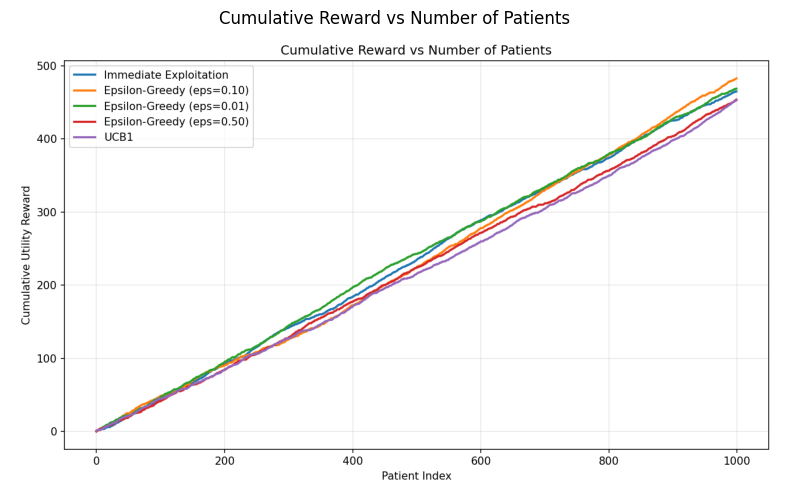

In [10]:
# Cumulative reward comparison plot
plot_cumulative(results, 'mab_cumulative_reward.png')
img = plt.imread('mab_cumulative_reward.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Cumulative Reward vs Number of Patients')
plt.show()


# Assignment Analysis and Observations

## Observations
1. Epsilon-Greedy (10%) balances exploration and exploitation effectively.
2. Epsilon-Greedy (1%) may converge too early and miss better medicines.
3. Epsilon-Greedy (50%) explores excessively and sacrifices reward accumulation.
4. UCB1 provides a principled exploration strategy and is generally the safest approach for real-world deployment because it continues gathering evidence while favoring promising treatments.

## Recommendation
For hospital deployment, UCB1 is recommended because it systematically balances learning and treatment quality, reducing the risk of locking onto a suboptimal medicine too early.
